DATA SCIENCE AND VISUALIZATION (24ADI204)
## TEAM 16

---


WEEK 3 - Data Cleaning and Visualising


## OBJETCIVE:
The objective of data cleaning is to improve the quality and consistency of the Chicago Crime dataset before performing further analysis and visualization. The cleaning process focuses on removing records with missing values in important non-geographical attributes, checking duplicate records, standardizing the date field, and handling geographical information separately. Geographical records with missing latitude and longitude are retained in the main dataset but excluded from geographical analysis. This ensures that useful crime records are preserved while the data used for hotspot mapping remains reliable.

### 1.Importing libraries and loading data

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")
import os

files = os.listdir('/content')

for file in files:
    if file.endswith('.csv'):
        print(file)
df = pd.read_csv('/content/Chicago_Crimes_2001_to_Present.csv')



Chicago_Crimes_2001_to_Present.csv


2.Copy original dataset

In [100]:
df_raw = df.copy()

print("Raw dataset stored successfully.")

Raw dataset stored successfully.


3.Data before cleaning

In [101]:
print("Before cleaning:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Total null values:", df.isnull().sum().sum())

# Columns where null values should be removed
columns_to_clean = [
    'Description',
    'Location Description',
    'Arrest',
    'Domestic',
    'Beat',
    'District',
    'FBI Code',
    'Year',
    'Updated On'
]


Before cleaning:
Rows: 2308203
Columns: 22
Total null values: 1332140


Check for valid dates

In [96]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

print("Invalid dates:", df['Date'].isna().sum())

Invalid dates: 0


Checking for outliers

In [102]:


print("Latitude:")
print("Minimum:", df['Latitude'].min())
print("Maximum:", df['Latitude'].max())

print("\nLongitude:")
print("Minimum:", df['Longitude'].min())
print("Maximum:", df['Longitude'].max())
invalid_latitude = (
    df['Latitude'].notna() &
    ~df['Latitude'].between(-90, 90)
)

invalid_longitude = (
    df['Longitude'].notna() &
    ~df['Longitude'].between(-180, 180)
)

print("Actually invalid Latitude:", invalid_latitude.sum())
print("Actually invalid Longitude:", invalid_longitude.sum())

Latitude:
Minimum: 36.619446395
Maximum: 42.022910333

Longitude:
Minimum: -91.686565684
Maximum: -87.524529378
Actually invalid Latitude: 0
Actually invalid Longitude: 0


Removing columns

Data after cleaning

In [103]:
df = df.dropna(subset=columns_to_clean)

print("\nAfter cleaning:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Total null values:", df.isnull().sum().sum())


After cleaning:
Rows: 2306683
Columns: 22
Total null values: 1326436


## Handling Geographical data:
Latitude and longitude were handled separately because they are essential for crime hotspot mapping. Records with missing geographical coordinates were retained in the main cleaned dataset so that they can still be used for non-geographical analysis. A separate geographical dataset was created by removing records without valid latitude and longitude, and this dataset will be used for hotspot visualization.

In [104]:
# Check missing geographical values
print("Missing Latitude:", df['Latitude'].isnull().sum())
print("Missing Longitude:", df['Longitude'].isnull().sum())

geo_df = df.dropna(subset=['Latitude', 'Longitude']).copy()
print("Total records:", len(df))
print("Records with valid coordinates:", len(geo_df))



Missing Latitude: 28458
Missing Longitude: 28458
Total records: 2306683
Records with valid coordinates: 2278225


Before Vs After Cleaning

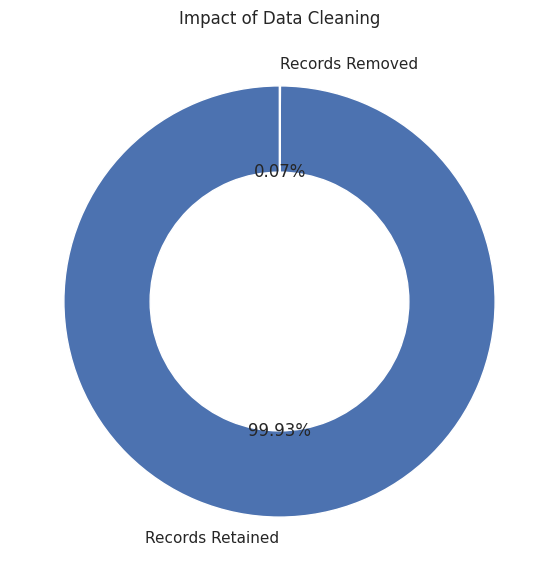

In [105]:
import matplotlib.pyplot as plt

retained = len(df)
removed = len(df_raw) - len(df)

values = [retained, removed]
labels = ['Records Retained', 'Records Removed']

plt.figure(figsize=(7,7))

plt.pie(
    values,
    labels=labels,
    autopct='%1.2f%%',
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title('Impact of Data Cleaning')

plt.show()

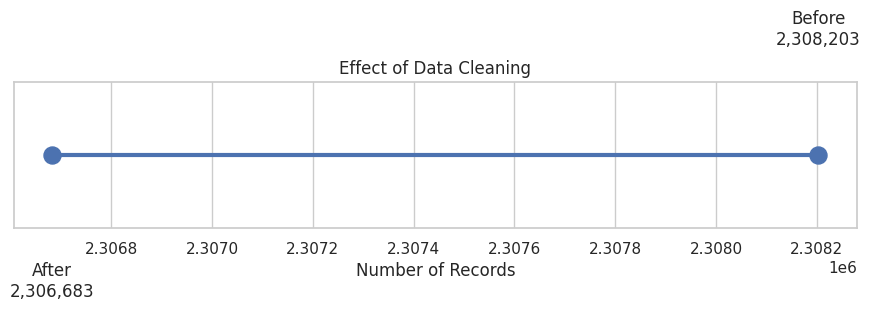

In [106]:
import matplotlib.pyplot as plt

before = len(df_raw)
after = len(df)

plt.figure(figsize=(9, 4))

plt.hlines(
    y=0,
    xmin=after,
    xmax=before,
    linewidth=3
)

plt.scatter([before, after], [0, 0], s=150)

plt.text(before, 0.08, f'Before\n{before:,}',
         ha='center', va='bottom')

plt.text(after, -0.08, f'After\n{after:,}',
         ha='center', va='top')

plt.yticks([])
plt.xlabel('Number of Records')
plt.title('Effect of Data Cleaning')

plt.tight_layout()
plt.show()

Geographical data availability chart

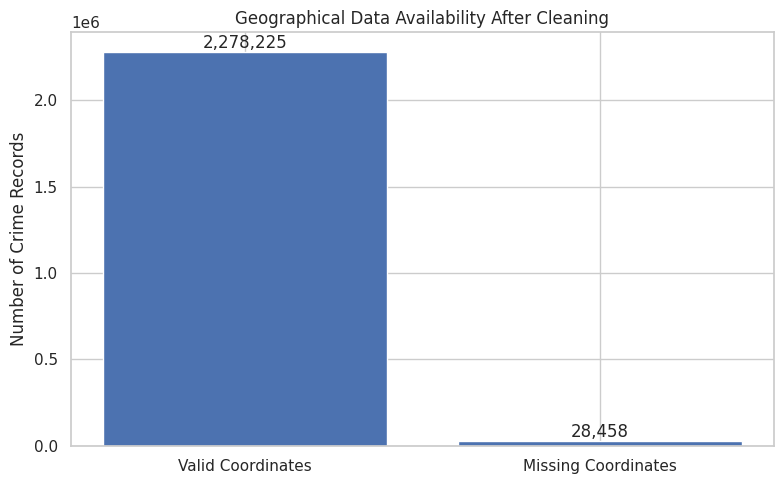

In [107]:
geo_missing = df[['Latitude', 'Longitude']].isnull().any(axis=1)

valid_geo = (~geo_missing).sum()
missing_geo = geo_missing.sum()

plt.figure(figsize=(8,5))

bars = plt.bar(
    ['Valid Coordinates', 'Missing Coordinates'],
    [valid_geo, missing_geo]
)

plt.title('Geographical Data Availability After Cleaning')
plt.ylabel('Number of Crime Records')

for bar, value in zip(bars, [valid_geo, missing_geo]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{value:,}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

Top 10 Crime Types After Cleaning

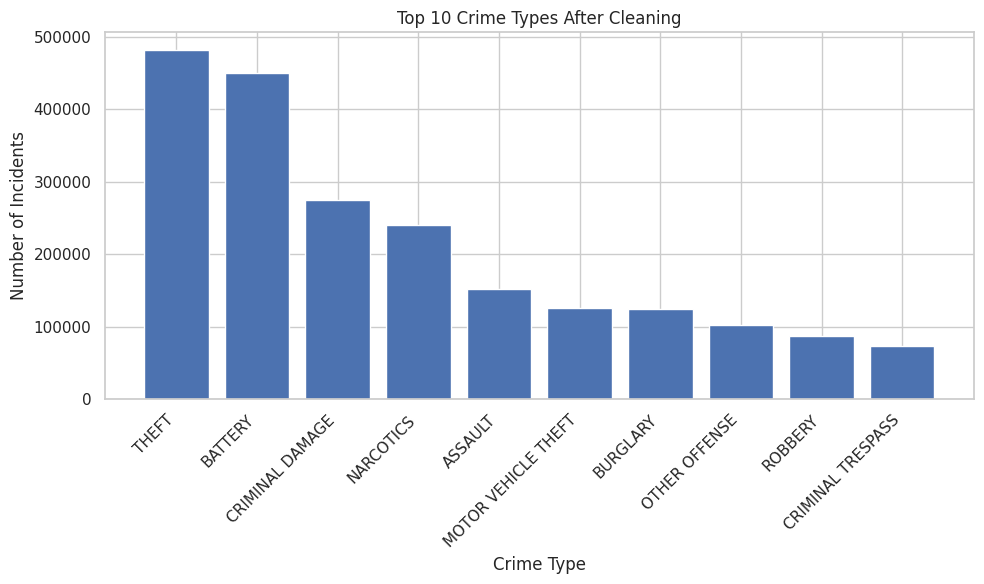

In [108]:
crime_counts = df['Primary Type'].value_counts().head(10)

plt.figure(figsize=(10,6))

bars = plt.bar(
    crime_counts.index,
    crime_counts.values
)

plt.title('Top 10 Crime Types After Cleaning')
plt.xlabel('Crime Type')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Crime Distribution by Time of Day

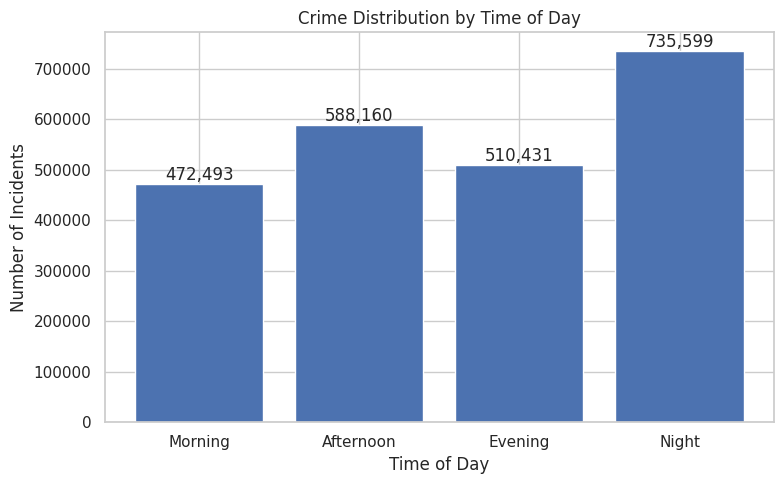

In [109]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df['Hour'] = df['Date'].dt.hour

def get_time_period(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['Time of Day'] = df['Hour'].apply(get_time_period)
order = ['Morning', 'Afternoon', 'Evening', 'Night']

time_counts = df['Time of Day'].value_counts().reindex(order)

plt.figure(figsize=(8,5))

bars = plt.bar(
    time_counts.index,
    time_counts.values
)

plt.title('Crime Distribution by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Number of Incidents')

for bar, value in zip(bars, time_counts.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{value:,}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

Outlier Analysis

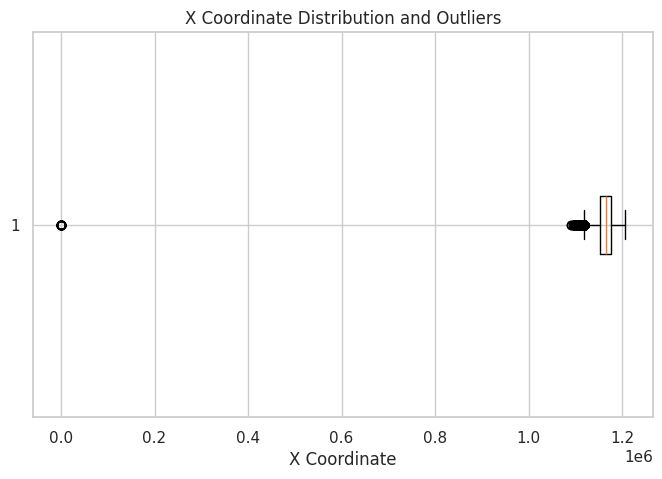

In [110]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    geo_df['X Coordinate'].dropna(),
    vert=False
)

plt.title('X Coordinate Distribution and Outliers')
plt.xlabel('X Coordinate')

plt.show()

Heat map of Crime by Day of Week × Time

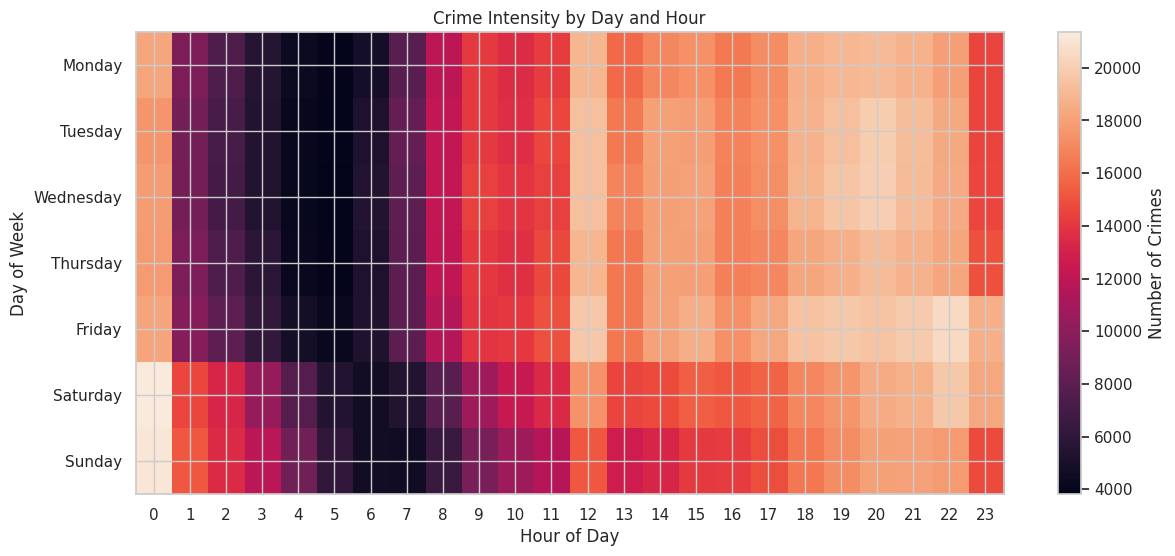

In [111]:
df['Day of Week'] = df['Date'].dt.day_name()
df['Hour'] = df['Date'].dt.hour

day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

heatmap_data = pd.crosstab(
    df['Day of Week'],
    df['Hour']
).reindex(day_order)

plt.figure(figsize=(14, 6))

plt.imshow(
    heatmap_data,
    aspect='auto'
)

plt.colorbar(label='Number of Crimes')

plt.xticks(range(24), range(24))
plt.yticks(range(7), day_order)

plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.title('Crime Intensity by Day and Hour')

plt.show()

Save cleaned dataset

In [113]:

df.to_csv('chicago_crime_cleaned.csv', index=False)

print("Cleaned dataset saved successfully!")
from google.colab import files

files.download('chicago_crime_cleaned.csv')

Cleaned dataset saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>